In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data=pd.read_csv("cleaned_sales.csv")

In [3]:
data.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,2017-08-11,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,2017-08-11,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,2017-12-06,NaN,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,2016-11-10,NaN,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,2016-11-10,NaN,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [4]:
data.shape

(9800, 18)

In [5]:
data.info

<bound method DataFrame.info of       Row ID        Order ID  Order Date   Ship Date       Ship Mode  \
0          1  CA-2017-152156  2017-08-11  2017-11-11    Second Class   
1          2  CA-2017-152156  2017-08-11  2017-11-11    Second Class   
2          3  CA-2017-138688  2017-12-06         NaN    Second Class   
3          4  US-2016-108966  2016-11-10         NaN  Standard Class   
4          5  US-2016-108966  2016-11-10         NaN  Standard Class   
...      ...             ...         ...         ...             ...   
9795    9796  CA-2017-125920         NaN         NaN  Standard Class   
9796    9797  CA-2016-128608  2016-12-01         NaN  Standard Class   
9797    9798  CA-2016-128608  2016-12-01         NaN  Standard Class   
9798    9799  CA-2016-128608  2016-12-01         NaN  Standard Class   
9799    9800  CA-2016-128608  2016-12-01         NaN  Standard Class   

     Customer ID     Customer Name    Segment        Country             City  \
0       CG-12520      

In [6]:
data.describe()

,Row ID,Postal Code,Sales
count,9800.000000,9800.000000,9800.000000
mean,4900.500000,55276.498571,230.769059
std,2829.160653,32023.374393,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


In [7]:
total_sales = data["Sales"].sum()

print(f"Total Sales: {total_sales:2f}")

Total Sales: 2261536.782700


In [8]:
total_orders = data["Order ID"].nunique()

print("Total Orders:", total_orders)

Total Orders: 4922


In [9]:
total_customers = data["Customer ID"].nunique()

print("Total Customers:", total_customers)

Total Customers: 793


In [10]:
average_order_value = total_sales / total_orders

print("Average Order Value:", round(average_order_value, 2))

Average Order Value: 459.48


In [11]:
category_sales = (
    data.groupby("Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

category_sales

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64

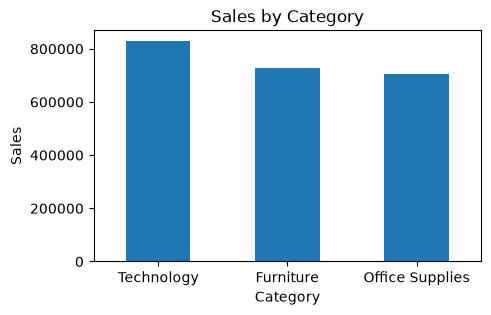

In [12]:
category_sales.plot(
    kind="bar",
    figsize=(5,3)
)

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.xticks(rotation=0)
plt.show()

In [13]:
subcategory_sales = (
    data.groupby("Sub-Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

subcategory_sales

Sub-Category
Phones         327782.4480
Chairs         322822.7310
Storage        219343.3920
Tables         202810.6280
Binders        200028.7850
Machines       189238.6310
Accessories    164186.7000
Copiers        146248.0940
Bookcases      113813.1987
Appliances     104618.4030
Furnishings     89212.0180
Paper           76828.3040
Supplies        46420.3080
Art             26705.4100
Envelopes       16128.0460
Labels          12347.7260
Fasteners        3001.9600
Name: Sales, dtype: float64

In [14]:
subcategory_sales.head(10)

Sub-Category
Phones         327782.4480
Chairs         322822.7310
Storage        219343.3920
Tables         202810.6280
Binders        200028.7850
Machines       189238.6310
Accessories    164186.7000
Copiers        146248.0940
Bookcases      113813.1987
Appliances     104618.4030
Name: Sales, dtype: float64

In [15]:
region_sales = (
    data.groupby("Region")["Sales"]
    .sum()
    .sort_values(ascending=False)
)
region_sales

Region
West       710219.6845
East       669518.7260
Central    492646.9132
South      389151.4590
Name: Sales, dtype: float64

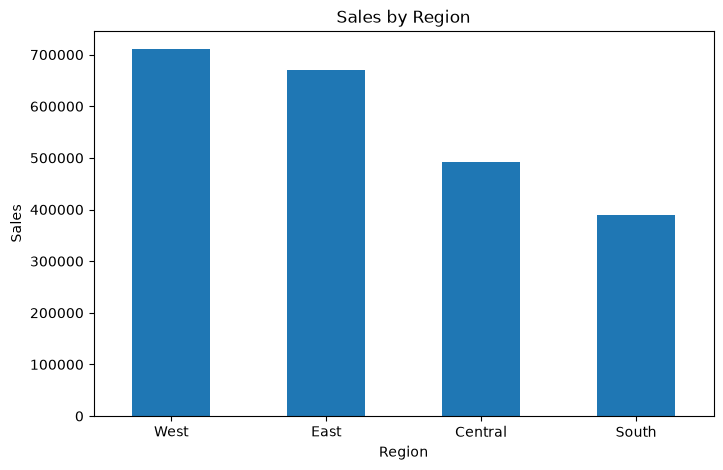

In [16]:
region_sales.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")
plt.xticks(rotation=0)
plt.show()

In [17]:
top_products = (
    data.groupby("Product Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64

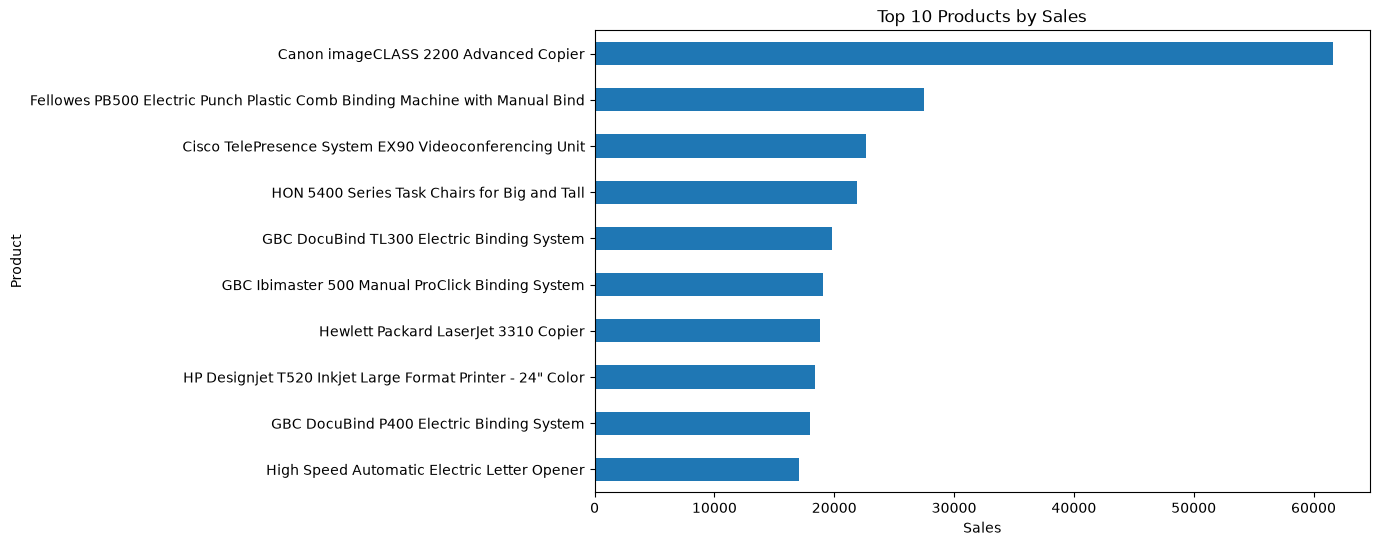

In [18]:
top_products.sort_values().plot(
    kind="barh",
    figsize=(10,6)
)

plt.title("Top 10 Products by Sales")
plt.xlabel("Sales")
plt.ylabel("Product")
plt.show()

In [19]:
top_customers = (
    data.groupby("Customer Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_customers

Customer Name
Sean Miller           25043.050
Tamara Chand          19052.218
Raymond Buch          15117.339
Tom Ashbrook          14595.620
Adrian Barton         14473.571
Ken Lonsdale          14175.229
Sanjit Chand          14142.334
Hunter Lopez          12873.298
Sanjit Engle          12209.438
Christopher Conant    12129.072
Name: Sales, dtype: float64

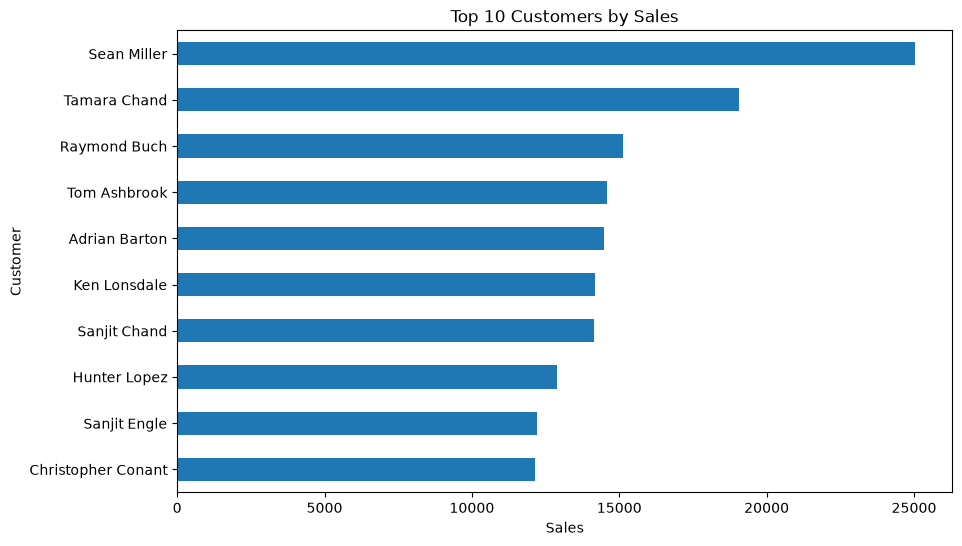

In [20]:
top_customers.sort_values().plot(
    kind="barh",
    figsize=(10,6)
)

plt.title("Top 10 Customers by Sales")
plt.xlabel("Sales")
plt.ylabel("Customer")
plt.show()

In [21]:
data["Order Date"] = pd.to_datetime(data["Order Date"])

In [22]:
monthly_sales = (
    data.groupby(
        data["Order Date"].dt.to_period("M")
    )["Sales"]
    .sum()
)

monthly_sales

Order Date
2015-01    19546.1630
2015-02    11678.9940
2015-03     6716.0440
2015-04    12455.4820
2015-05    15165.0510
2015-06    11884.1690
2015-07    10075.7400
2015-08    26797.7630
2015-09    17158.9320
2015-10    10112.6410
2015-11    18349.7640
2015-12    17045.8427
2016-01    17701.6864
2016-02    13018.3150
2016-03    12207.4066
2016-04    11963.6960
2016-05    10483.4820
2016-06    13026.6682
2016-07    10706.7200
2016-08    22782.5770
2016-09    16484.9010
2016-10    12293.0380
2016-11    12139.0395
2016-12     9761.3330
2017-01    26342.5410
2017-02    42967.9150
2017-03    25982.2870
2017-04    19472.1640
2017-05    22649.3888
2017-06    14050.1430
2017-07    16501.0070
2017-08    24156.3226
2017-09     9789.6620
2017-10    22599.7820
2017-11    20378.2400
2017-12    21365.1485
2018-01    27367.5920
2018-02    36285.9360
2018-03    26882.9530
2018-04    21203.6070
2018-05    15979.1570
2018-06    12138.1558
2018-07    25110.4795
2018-08    26823.6900
2018-09    23148.8700

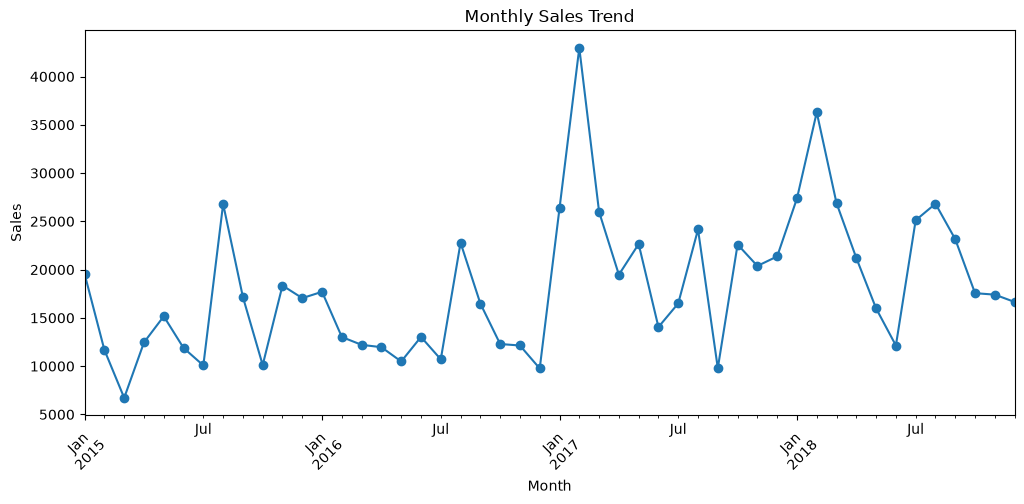

In [23]:
monthly_sales.plot(
    kind="line",
    figsize=(12,5),
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show()

In [24]:
yearly_sales = (
    data.groupby(
        data["Order Date"].dt.year
    )["Sales"]
    .sum()
)

yearly_sales

Order Date
2015.0    176986.5857
2016.0    162568.8627
2017.0    266254.6009
2018.0    266553.0743
Name: Sales, dtype: float64

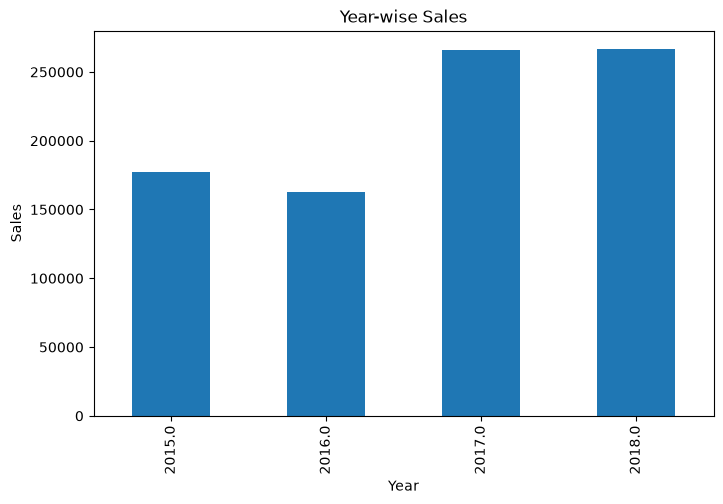

In [25]:
yearly_sales.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Year-wise Sales")
plt.xlabel("Year")
plt.ylabel("Sales")
plt.show()

In [26]:
shipmode_sales = (
    data.groupby("Ship Mode")["Sales"]
    .sum()
    .sort_values(ascending=False)
).round(2)

shipmode_sales

Ship Mode
Standard Class    1340831.31
Second Class       449914.18
First Class        345572.26
Same Day           125219.04
Name: Sales, dtype: float64

In [27]:
segment_sales = (
    data.groupby("Segment")["Sales"]
    .sum()
    .sort_values(ascending=False)
).round(2)

segment_sales




Segment
Consumer       1148060.53
Corporate       688494.07
Home Office     424982.18
Name: Sales, dtype: float64

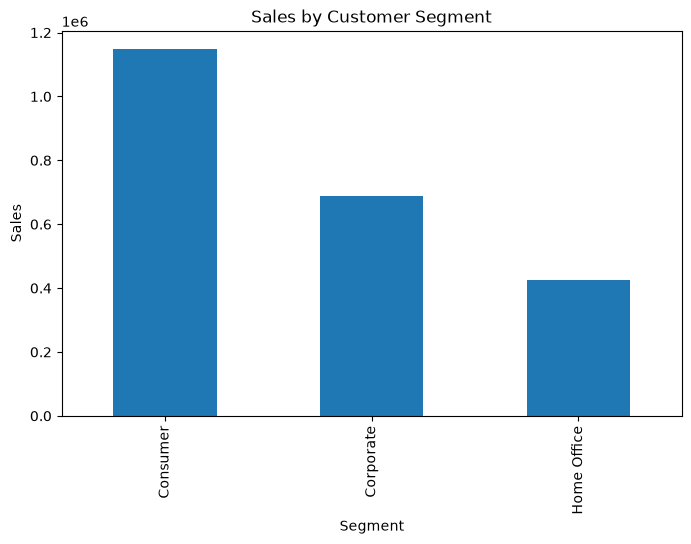

In [28]:
segment_sales.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Sales by Customer Segment")
plt.xlabel("Segment")
plt.ylabel("Sales")
plt.show()

In [29]:
print("Total Sales:", total_sales)
print("Total Orders:", total_orders)
print("Total Customers:", total_customers)

print("\nTop Category:")
print(category_sales.head(1))

print("\nTop Region:")
print(region_sales.head(1))

print("\nTop Product:")
print(top_products.head(1))

print("\nTop Customer:")
print(top_customers.head(1))

Total Sales: 2261536.7827
Total Orders: 4922
Total Customers: 793

Top Category:
Category
Technology    827455.873
Name: Sales, dtype: float64

Top Region:
Region
West    710219.6845
Name: Sales, dtype: float64

Top Product:
Product Name
Canon imageCLASS 2200 Advanced Copier    61599.824
Name: Sales, dtype: float64

Top Customer:
Customer Name
Sean Miller    25043.05
Name: Sales, dtype: float64
